
# ШАГ 1: Академический текст
## 1. Постановка задачи кластеризации
Пусть дано множество наблюдений (точек) $X={x1​,x2​,…,xn​}$, где каждая точка описывается парой координат на плоскости: $xi​=(siti1​,siti2​)∈R2$. Наша цель — разбить эти точки на $K$ непересекающихся групп (кластеров).
Математически алгоритм ищет такие координаты центров кластеров (центроидов) $C={c1​,c2​,…,cK​}$ и такое распределение точек по группам, чтобы минимизировать метрику SSE (Sum of Squared Errors) — сумму квадратов расстояний от точек до центров их кластеров:
$J=i=1∑n​j=1∑K​wij​∥xi​−cj​∥2→min$
Где $wij​=1$, если точка $xi​$ назначена кластеру $j$, и $wij​=0$ в противном случае.
## 2. Две фазы итерационного процесса Ллойда
Поскольку найти глобальный минимум перебором невозможно, алгоритм работает циклически, чередуя два шага:
E-шаг (Expectation / Ожидание): Центроиды зафиксированы. Каждая точка на плоскости считает евклидово расстояние до всех центров и «выбирает» ближайший. В интерактивном приложении этот шаг соответствует фазе Assign — точки мгновенно окрашиваются в цвет своего центра.
M-шаг (Maximization / Максимизация): Состав кластеров зафиксирован. Каждый центроид пересчитывает свои координаты, сдвигаясь в геометрический центр тяжести (среднее арифметическое координат) всех закрепленных за ним точек. В приложении этот шаг соответствует фазе Update — центроиды плавно перемещаются на новые позиции.
### Процесс завершается (Converged), когда на очередном шаге ни одна точка не меняет свой кластер, а центроиды перестают смещаться


# Математический анализ алгоритма K-Means с использованием библиотеки Scikit-Learn
В данном ноутбуке демонстрируется процесс генерации искусственной двумерной выборки (облака точек), инициализация и обучение модели K-Means, а также визуализация итерационного процесса и графика функции потерь (Inertia/SSE).

In [1]:
# Шаг 1: Импорт необходимых вычислительных и графических библиотек
import os
os.environ["OMP_NUM_THREADS"] = "2"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Настройка стиля графиков для академического отчета
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


## Шаг 2: Генерация синтетического датасета
Сгенерируем изотропные гауссовские облака точек (кластеры) на плоскости для имитации реальной задачи сегментации, аналогично функции "Generate Points" в веб-приложении.

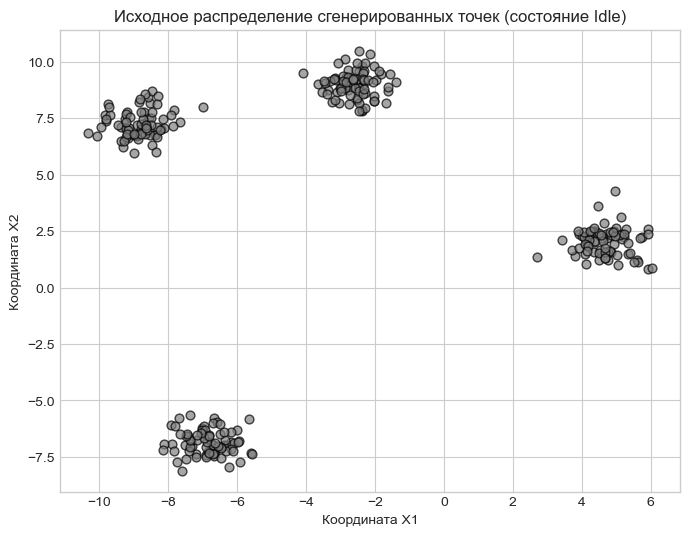

In [2]:
# Фиксируем seed для воспроизводимости эксперимента
random_state = 42

# Генерируем 300 точек, распределенных по 4 явным центрам
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=random_state)

# Визуализация исходного распределения некодированных данных
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=40, color='gray', alpha=0.7, edgecolors='black')
plt.title("Исходное распределение сгенерированных точек (состояние Idle)", fontsize=12)
plt.xlabel("Координата X1")
plt.ylabel("Координата X2")
plt.show()

## Шаг 3: Кластеризация методом K-Means
Инициализируем алгоритм. Задаем $K=4$ кластера. Для анализа сходимости проведем обучение и извлечем финальные метрики (координаты центроидов и значение SSE).

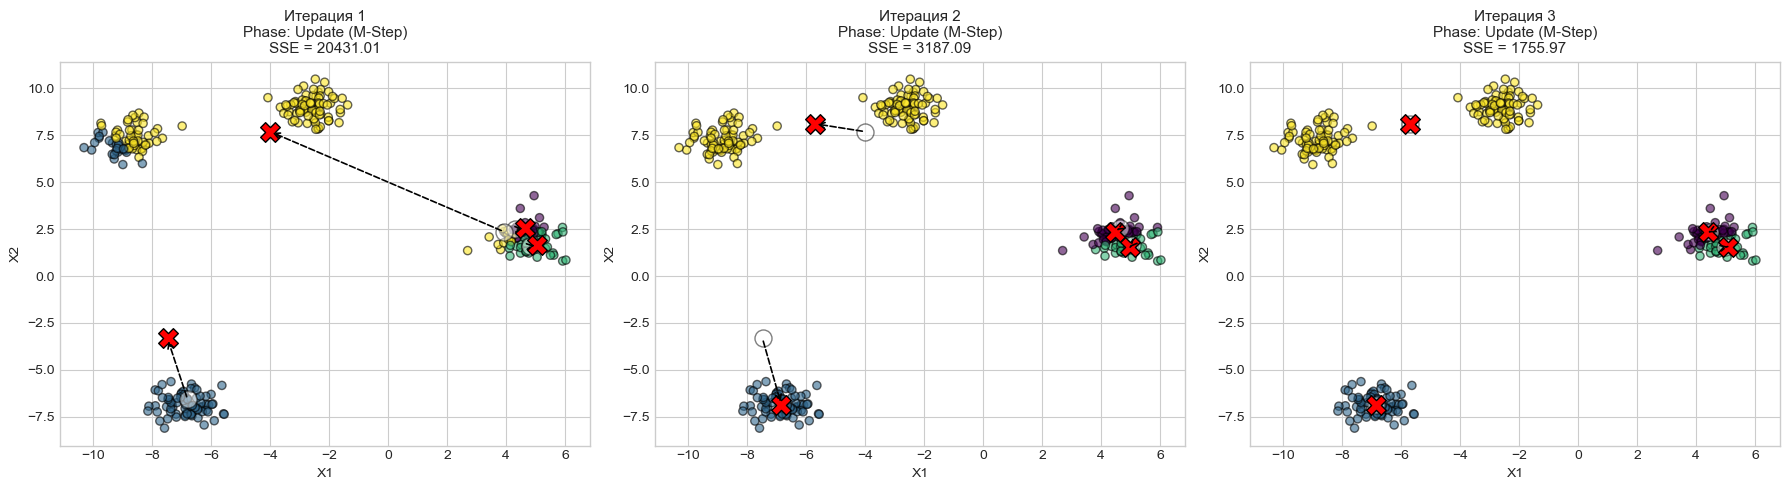

In [7]:
# Выбираем случайные точки из датасета в качестве начальных центроидов
np.random.seed(42)
initial_idx = np.random.choice(X.shape[0], 4, replace=False)
current_centroids = X[initial_idx]

centroids_history = [current_centroids.copy()]
labels_history = []
sse_history = []

# Запускаем ручной расчет на 3 шага, чтобы отследить динамику сходимости
max_steps = 3
for step in range(1, max_steps + 1):
    # 1. E-ШАГ: Расчет расстояний и привязка точек к ближайшим центрам
    distances = np.linalg.norm(X[:, np.newaxis] - current_centroids, axis=2)
    current_labels = np.argmin(distances, axis=1)
    labels_history.append(current_labels)
    
    # Расчет метрики функции потерь (SSE) для текущего шага
    current_sse = 0
    for j in range(4):
        cluster_points = X[current_labels == j]
        if len(cluster_points) > 0:
            current_sse += np.sum(np.linalg.norm(cluster_points - current_centroids[j], axis=1)**2)
    sse_history.append(current_sse)
    
    # 2. М-ШАГ: Пересчет центров как среднее арифметическое координат точек кластера
    new_centroids = np.array([X[current_labels == j].mean(axis=0) if len(X[current_labels == j]) > 0 
                              else current_centroids[j] for j in range(4)])
    
    centroids_history.append(new_centroids.copy())
    
    # Проверка критерия остановки
    if np.allclose(current_centroids, new_centroids):
        print(f"Алгоритм стабилизировался на итерации {step-1}.")
        break
        
    current_centroids = new_centroids

# Построение графиков для каждой итерации процесса
fig, axes = plt.subplots(1, len(labels_history), figsize=(6 * len(labels_history), 5))
if len(labels_history) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    # Отрисовка точек текущего кластера
    ax.scatter(X[:, 0], X[:, 1], c=labels_history[i], s=35, cmap='viridis', alpha=0.6, edgecolors='black')
    
    # Предыдущее положение центроидов (белые круги)
    ax.scatter(centroids_history[i][:, 0], centroids_history[i][:, 1], c='white', s=150, marker='o', edgecolors='black', alpha=0.5)
    
    # Новое положение центроидов (красные кресты)
    ax.scatter(centroids_history[i+1][:, 0], centroids_history[i+1][:, 1], c='red', s=200, marker='X', edgecolors='black')
    
    # Отрисовка векторов (стрелок) смещения центров
    for j in range(4):
        ax.annotate('', xy=(centroids_history[i+1][j, 0], centroids_history[i+1][j, 1]),
                    xytext=(centroids_history[i][j, 0], centroids_history[i][j, 1]),
                    arrowprops=dict(arrowstyle="->", color='black', lw=1.2, ls='--'))
        
    ax.set_title(f"Итерация {i+1}\nPhase: Update (M-Step)\nSSE = {sse_history[i]:.2f}", fontsize=11)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

plt.tight_layout()
plt.show()

## Шаг 4: Итоговая визуализация разделения
Отобразим результаты работы алгоритма: покрасим точки в соответствии с присвоенными метками кластеров и нанесем на плоскость вычисленные центроиды.

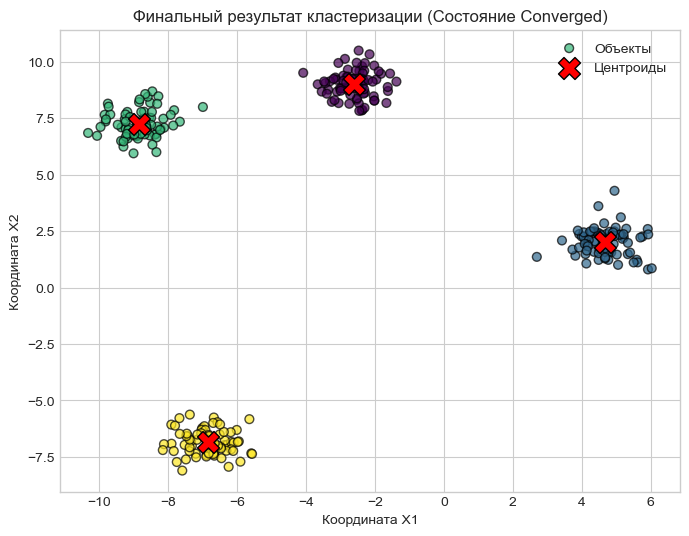

In [8]:
plt.figure(figsize=(8, 6))

# Отрисовка точек с цветовой кодировкой кластеров
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', alpha=0.7, edgecolors='black', label='Объекты')

# Отрисовка центроидов кластеров (выделены крупными красными маркерами)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=250, marker='X', edgecolors='black', label='Центроиды')

plt.title("Финальный результат кластеризации (Состояние Converged)", fontsize=12)
plt.xlabel("Координата X1")
plt.ylabel("Координата X2")
plt.legend(loc='best')
plt.show()

## Шаг 5: Анализ динамики изменения SSE (Метод локтя)
Покажем, как ведет себя целевая функция при изменении параметра количества кластеров $K$. Это позволяет определить оптимальное разбиение данных, когда структура заранее неизвестна.

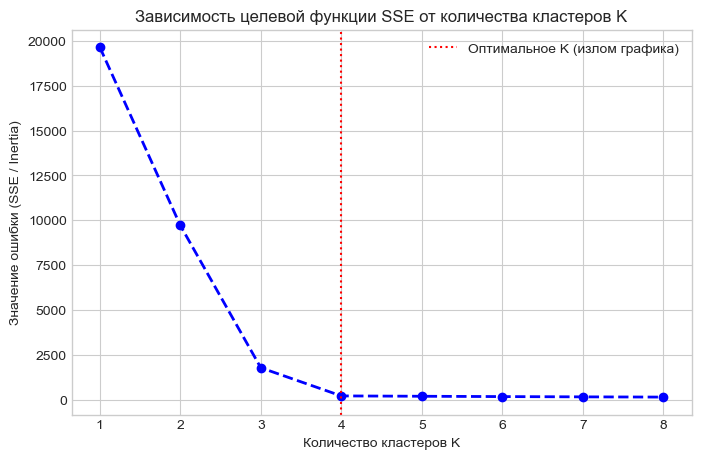

In [9]:
sse_list = []
k_range = range(1, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='random', n_init=5, random_state=random_state)
    km.fit(X)
    sse_list.append(km.inertia_)

# Построение графика "Локтя"
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse_list, marker='o', linestyle='--', color='blue', linewidth=2)
plt.title("Зависимость целевой функции SSE от количества кластеров K", fontsize=12)
plt.xlabel("Количество кластеров K")
plt.ylabel("Значение ошибки (SSE / Inertia)")
plt.xticks(k_range)
plt.axvline(x=4, color='red', linestyle=':', label='Оптимальное K (излом графика)')
plt.legend()
plt.show()